In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
import seaborn as sn
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('/content/02-logistic-regression-dataset-task-2.csv')

print("Dataset Shape:", data.shape)
display(data.head())

Dataset Shape: (36, 4)


,Disease,Age,Gender,Smoker_status
0,diseased,43,Male,Smoker
1,not diseased,18,Male,Smoker
2,diseased,22,Female,Non-smoker
3,diseased,25,Male,Non-smoker
4,not diseased,45,Female,Smoker


In [3]:
print("\nNull values in dataset:")
print(data.isnull().sum())


Null values in dataset:
Disease          0
Age              0
Gender           0
Smoker_status    0
dtype: int64


In [12]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

print("\nClasses identified in the target variable:", label_encoder.classes_)


Classes identified in the target variable: ['Non-smoker' 'Smoker']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

print("\nShapes of splits (X_train, y_train, X_test, y_test):")
display(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
X = pd.get_dummies(X, drop_first=True)


Shapes of splits (X_train, y_train, X_test, y_test):


(28, 3)

(28,)

(8, 3)

(8,)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

print("\nShapes of splits (X_train, y_train, X_test, y_test):")
display(X_train.shape, y_train.shape, X_test.shape, y_test.shape)


Shapes of splits (X_train, y_train, X_test, y_test):


(28, 3)

(28,)

(8, 3)

(8,)

In [17]:
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [19]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)
print('\nConfusion Matrix:\n', conf_mat)

Accuracy_score = metrics.accuracy_score(y_test, y_pred)
print('Accuracy Score :', Accuracy_score)
print('Accuracy in Percentage:', int(Accuracy_score * 100), '%')


Confusion Matrix:
 [[1 2]
 [0 5]]
Accuracy Score : 0.75
Accuracy in Percentage: 75 %


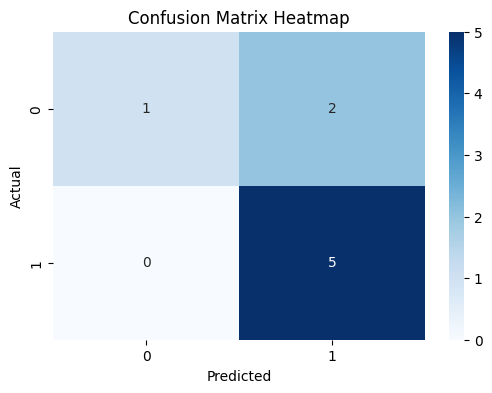

In [20]:
conf_mat_df = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
plt.figure(figsize=(6, 4))
sn.heatmap(conf_mat_df, annot=True, cmap='Blues', fmt='g')
plt.title('Confusion Matrix Heatmap')
plt.show()